# 🏬 **Sales Forecasting Across Multiple Retail Stores**

### *An End-to-End Forecasting Pipeline for Rossmann Pharmaceuticals' Retail Network*

---

**Author**  : Yousuf S. R. Sakkaf

**Status**  : Completed

**Dataset** : store_train_data.csv , store_test_data.csv

**File**    : 03_salesfc_deep_learning.ipynb

**Project** : NHIS_Project6

**Date**    : 7th September 2026

---

## 🛠 Environment Setup

In [1]:
import os
import urllib.request

PREREQUISITES_GITHUB_URL = "https://raw.githubusercontent.com/S-Yousuf-S/NHIS_Project6/main/prerequisites.py"

if not os.path.exists("prerequisites.py"):
    print("🌐 prerequisites.py not found locally — downloading from GitHub...")
    urllib.request.urlretrieve(PREREQUISITES_GITHUB_URL, "prerequisites.py")
    print("💾 prerequisites.py downloaded and saved for this session.")
else:
    print("✅ prerequisites.py found locally.")

✅ prerequisites.py found locally.


In [2]:
from prerequisites import *
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
import gc
import joblib
import warnings
warnings.filterwarnings("ignore", message=".*force_all_finite.*", category=FutureWarning)

logger = setup_logging(notebook_name="03_salesfc_deep_learning")

# Seed TensorFlow separately from NumPy/sklearn's random_state=42 convention —
# neural network weight initialization and training have their own randomness source
tf.random.set_seed(42)

2026-09-08 14:45:39 - 03_salesfc_deep_learning - INFO - Logging session started for '03_salesfc_deep_learning' -> Logs/YS_03_salesfc_deep_learning_20260908.log


### 🎨 Configure Notebook & Visualization Settings

In [3]:
set_global_visualization_settings(palette="viridis")

✅ Global visualization settings are ready.


## 01. Loading the Modeling-Ready Datasets

<div style="margin-left: 20px; max-width: 90%">

This notebook starts fresh from the same exported CSVs used in Notebook 2 (`store_train_data.csv`/`store_test_data.csv`) — unencoded, unscaled by design — since LSTM requires its own distinct preprocessing (categorical encoding, differencing, sliding-window transformation) that differs fundamentally from the tree-based pipeline built in Notebook 2.

</div>

In [4]:
section_header("Loading Modeling-Ready Datasets")

DRIVE_TRAIN_PATH = "/content/drive/MyDrive/NHIS_Project/Project 6/Assets/store_train_data.csv"
DRIVE_TEST_PATH = "/content/drive/MyDrive/NHIS_Project/Project 6/Assets/store_test_data.csv"
GITHUB_RAW_BASE = "https://raw.githubusercontent.com/S-Yousuf-S/NHIS_Project6/main/Assets"

store_train_dl = load_data_file(
    "store_train_data.csv", drive_path=DRIVE_TRAIN_PATH, github_raw_base=GITHUB_RAW_BASE, logger=logger
)
store_test_dl = load_data_file(
    "store_test_data.csv", drive_path=DRIVE_TEST_PATH, github_raw_base=GITHUB_RAW_BASE, logger=logger
)

store_train_dl["Date"] = pd.to_datetime(store_train_dl["Date"])
store_test_dl["Date"] = pd.to_datetime(store_test_dl["Date"])

info_box(f"Loaded modeling-ready datasets — Train: <b>{store_train_dl.shape[0]:,}</b> rows, <b>{store_train_dl.shape[1]}</b> columns | "
         f"Test: <b>{store_test_dl.shape[0]:,}</b> rows, <b>{store_test_dl.shape[1]}</b> columns.")

centered_table(store_train_dl.head())

logger.info(f"Loaded store_train_data.csv (shape={store_train_dl.shape}) and store_test_data.csv (shape={store_test_dl.shape}) for LSTM pipeline.")

2026-09-08 14:45:39 - 03_salesfc_deep_learning - INFO - Loaded 'store_train_data.csv' from local Assets/ folder.


2026-09-08 14:45:42 - 03_salesfc_deep_learning - INFO - Loaded 'store_test_data.csv' from local Assets/ folder.


Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Promo2_Duration_Weeks,CompetitionOpen_Duration_Months,CompetitionOpenDate_Known,Year,Month,Day,WeekOfYear,Quarter,IsWeekend,MonthPosition,DaysToNextHoliday,DaysSinceLastHoliday,IsPromo2Month
1,2,2013-01-01,0,0,0,0,a,1,c,a,1270.00,0,0,52,1,2013,1,1,1,1,0,Start,0,0,0
1,3,2013-01-02,5530,668,1,0,0,1,c,a,1270.00,0,0,52,1,2013,1,2,1,1,0,Start,4,1,0
1,4,2013-01-03,4327,578,1,0,0,1,c,a,1270.00,0,0,52,1,2013,1,3,1,1,0,Start,3,2,0
1,5,2013-01-04,4486,619,1,0,0,1,c,a,1270.00,0,0,52,1,2013,1,4,1,1,0,Start,2,3,0
1,6,2013-01-05,4997,635,1,0,0,1,c,a,1270.00,0,0,52,1,2013,1,5,1,1,1,Start,1,4,0


2026-09-08 14:45:42 - 03_salesfc_deep_learning - INFO - Loaded store_train_data.csv (shape=(1017209, 26)) and store_test_data.csv (shape=(41088, 25)) for LSTM pipeline.


## 02. Encoding Categorical Features (Deferred from Notebook 1)

<div style="margin-left: 20px; max-width: 90%">

Notebook 1 deliberately exported unencoded, unscaled data so each downstream notebook could apply the encoding approach suited to its own model architecture. For the LSTM, categorical features are one-hot encoded directly on the dataframe (rather than via an `sklearn` `ColumnTransformer`, which is specific to Notebook 2's pipeline-based models) — a plain numeric matrix is what feeds into a Keras sequence model.

</div>

In [5]:
section_header("Encoding Categorical Features")
subsection_header("One-Hot Encoding Categorical Columns")

categorical_cols_dl = ["StoreType", "Assortment", "StateHoliday", "MonthPosition", "DayOfWeek"]

for col in categorical_cols_dl:
    logger.debug(f"Encoding categorical column: {col} ({store_train_dl[col].nunique()} unique values)")

store_train_encoded = pd.get_dummies(store_train_dl, columns=categorical_cols_dl, drop_first=False)
store_test_encoded = pd.get_dummies(store_test_dl, columns=categorical_cols_dl, drop_first=False)

# Align columns — test set may not contain every category value train does (or vice versa)
store_train_encoded, store_test_encoded = store_train_encoded.align(store_test_encoded, join="left", axis=1, fill_value=0)

success_box(f"Categorical features one-hot encoded — store_train_encoded: <b>{store_train_encoded.shape[1]}</b> columns, "
            f"store_test_encoded: <b>{store_test_encoded.shape[1]}</b> columns (aligned to match).")

logger.info(f"One-hot encoding complete. store_train_encoded shape: {store_train_encoded.shape}, store_test_encoded shape: {store_test_encoded.shape}.")

2026-09-08 14:45:42 - 03_salesfc_deep_learning - DEBUG - Encoding categorical column: StoreType (4 unique values)
2026-09-08 14:45:42 - 03_salesfc_deep_learning - DEBUG - Encoding categorical column: Assortment (3 unique values)
2026-09-08 14:45:42 - 03_salesfc_deep_learning - DEBUG - Encoding categorical column: StateHoliday (4 unique values)
2026-09-08 14:45:42 - 03_salesfc_deep_learning - DEBUG - Encoding categorical column: MonthPosition (3 unique values)
2026-09-08 14:45:42 - 03_salesfc_deep_learning - DEBUG - Encoding categorical column: DayOfWeek (7 unique values)


2026-09-08 14:45:43 - 03_salesfc_deep_learning - INFO - One-hot encoding complete. store_train_encoded shape: (1017209, 42), store_test_encoded shape: (41088, 42).


## 03. Time Series Construction (Store-Aware)

<div style="margin-left: 20px; max-width: 90%">

An LSTM needs data shaped as ordered sequences, not independent rows — but this dataset has over 1,100 interleaved store timelines mixed together. Naively slicing sequences across the raw row order would create sequences that jump between unrelated stores. This section sorts by `Store` then `Date` so every store's history is contiguous, which is a prerequisite for every later step (stationarity checks, sliding-window construction) to operate correctly per-store rather than across store boundaries.

</div>

In [6]:
section_header("Time Series Construction (Store-Aware)")
subsection_header("Sorting for Per-Store Chronological Continuity")

store_train_encoded = store_train_encoded.sort_values(["Store", "Date"]).reset_index(drop=True)
store_test_encoded = store_test_encoded.sort_values(["Store", "Date"]).reset_index(drop=True)

store_counts_train = store_train_encoded["Store"].nunique()
date_range_train = f"{store_train_encoded['Date'].min().date()} to {store_train_encoded['Date'].max().date()}"

success_box(f"Data sorted store-aware (Store, then Date) — <b>{store_counts_train}</b> unique stores, "
            f"date range <b>{date_range_train}</b>. Every store's rows are now chronologically contiguous.")

logger.info(f"Store-aware sort complete. {store_counts_train} unique stores, date range {date_range_train}.")

2026-09-08 14:45:43 - 03_salesfc_deep_learning - INFO - Store-aware sort complete. 1115 unique stores, date range 2013-01-01 to 2015-07-31.


## 04. Stationarity Check (Augmented Dickey-Fuller Test)

<div style="margin-left: 20px; max-width: 90%">

Before any sliding-window transformation, the Sales series needs to be checked for stationarity — a time series whose statistical properties (mean, variance) stay stable over time, which most forecasting-friendly models assume. This is tested using the Augmented Dickey-Fuller (ADF) test on an aggregate daily Sales series (summed across all open stores, since testing per-store individually — 1,115 separate tests — would be excessive for a single stationarity decision that applies to the whole modeling approach).

The null hypothesis is that the series is non-stationary; a small p-value (typically < 0.05) rejects that, indicating stationarity.

</div>

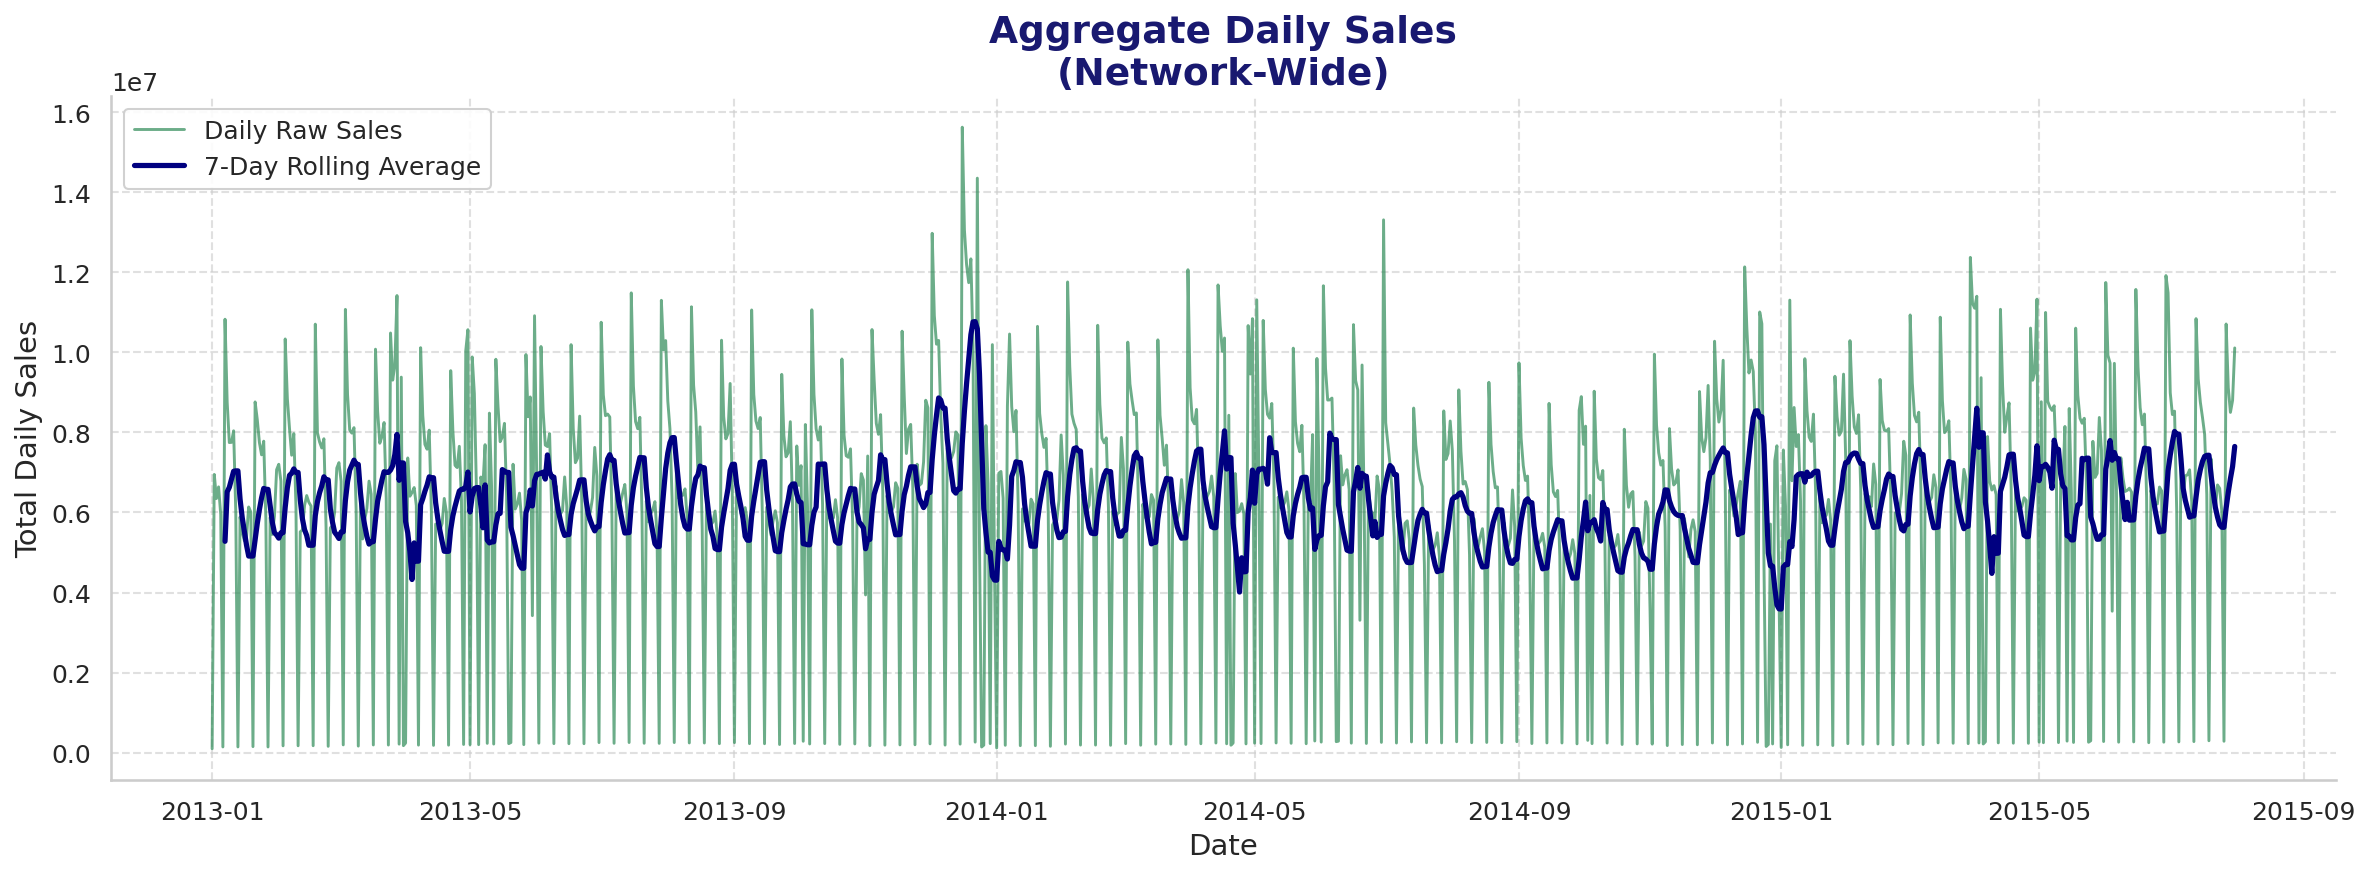

2026-09-08 14:45:44 - 03_salesfc_deep_learning - INFO - Aggregate daily sales series built. 942 daily observations, 2013-01-01 to 2015-07-31.


In [7]:
section_header("Stationarity Check (ADF Test)")
subsection_header("Aggregating to a Daily Sales Series")

# Aggregate daily sales
daily_sales = store_train_encoded[store_train_encoded["Open"] == 1].groupby("Date")["Sales"].sum().sort_index()

# Calculate a 7-day rolling average to smooth the Sunday drop-offs
rolling_7d = daily_sales.rolling(window=7).mean()

fig, ax = plt.subplots(figsize=(16, 6))

# Plot raw daily sales in the background
ax.plot(daily_sales.index, daily_sales.values, color="seagreen", linewidth=1.4, alpha=0.7, label="Daily Raw Sales")

# Overlay the 7-day rolling average in the foreground
ax.plot(rolling_7d.index, rolling_7d.values, color="navy", linewidth=2.5, label="7-Day Rolling Average")

ax.set_title("Aggregate Daily Sales\n(Network-Wide)", fontweight='bold', fontsize=18)
ax.set_ylabel("Total Daily Sales")
ax.set_xlabel("Date")
ax.legend(loc="upper left", framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('Assets/DL_daily_sales_series.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info(f"Aggregate daily sales series built. {len(daily_sales)} daily observations, {daily_sales.index.min().date()} to {daily_sales.index.max().date()}.")

In [8]:
subsection_header("Running the Augmented Dickey-Fuller Test")

adf_result = adfuller(daily_sales)
adf_statistic, adf_pvalue = adf_result[0], adf_result[1]

adf_summary = pd.DataFrame([{
    "ADF Statistic": f"{adf_statistic:.4f}",
    "p-value": f"{adf_pvalue:.6f}",
    "Critical Value (1%)": f"{adf_result[4]['1%']:.4f}",
    "Critical Value (5%)": f"{adf_result[4]['5%']:.4f}",
    "Critical Value (10%)": f"{adf_result[4]['10%']:.4f}"
}])
centered_table(adf_summary)

if adf_pvalue < 0.05:
    success_box(f"ADF p-value <b>({adf_pvalue:.6f})</b> is below 0.05 — the null hypothesis of non-stationarity is rejected. "
                "The series is stationary; <b>differencing is NOT required.</b>")
else:
    warning_box(f"ADF p-value <b>({adf_pvalue:.6f})</b> is above 0.05 — the series is non-stationary. "
                "<b>Differencing will be applied</b> in the next section.")

logger.info(f"ADF test complete. Statistic: {adf_statistic:.4f}, p-value: {adf_pvalue:.6f}.")

ADF Statistic,p-value,Critical Value (1%),Critical Value (5%),Critical Value (10%)
-4.7616,0.000064,-3.4375,-2.8647,-2.5684


2026-09-08 14:45:45 - 03_salesfc_deep_learning - INFO - ADF test complete. Statistic: -4.7616, p-value: 0.000064.


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Stationarity Check (ADF Test):**

- The Augmented Dickey-Fuller test rejects non-stationarity decisively (statistic -4.7616, well beyond the 1% critical value of -3.4375; p = 0.000064) — the aggregate daily sales series is stationary as-is.
- This isn't the result of any transformation — the raw series has no long-term trend or drifting mean over the full 2013-2015 window; it oscillates around a broadly stable level throughout, with the 7-day rolling average confirming this visually (a recurring seasonal hump each November-December, and one standout spike in December 2013, but no sustained upward or downward drift).
- Since the null hypothesis is rejected, **differencing is not required** — the brief's step "depending on your conclusion, difference your time series data" resolves to "no differencing needed" here, and the next step (ACF/PACF) proceeds directly on the undifferenced series.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 05. ACF/PACF Analysis

<div style="margin-left: 20px; max-width: 90%">

This section checks for autocorrelation and partial autocorrelation in the (already-confirmed-stationary) daily sales series.

The ACF/PACF plots reveal how many past days' sales meaningfully predict today's — direct evidence for choosing the LSTM's lookback window size in the upcoming sliding-window transformation, rather than picking that window arbitrarily.

</div>

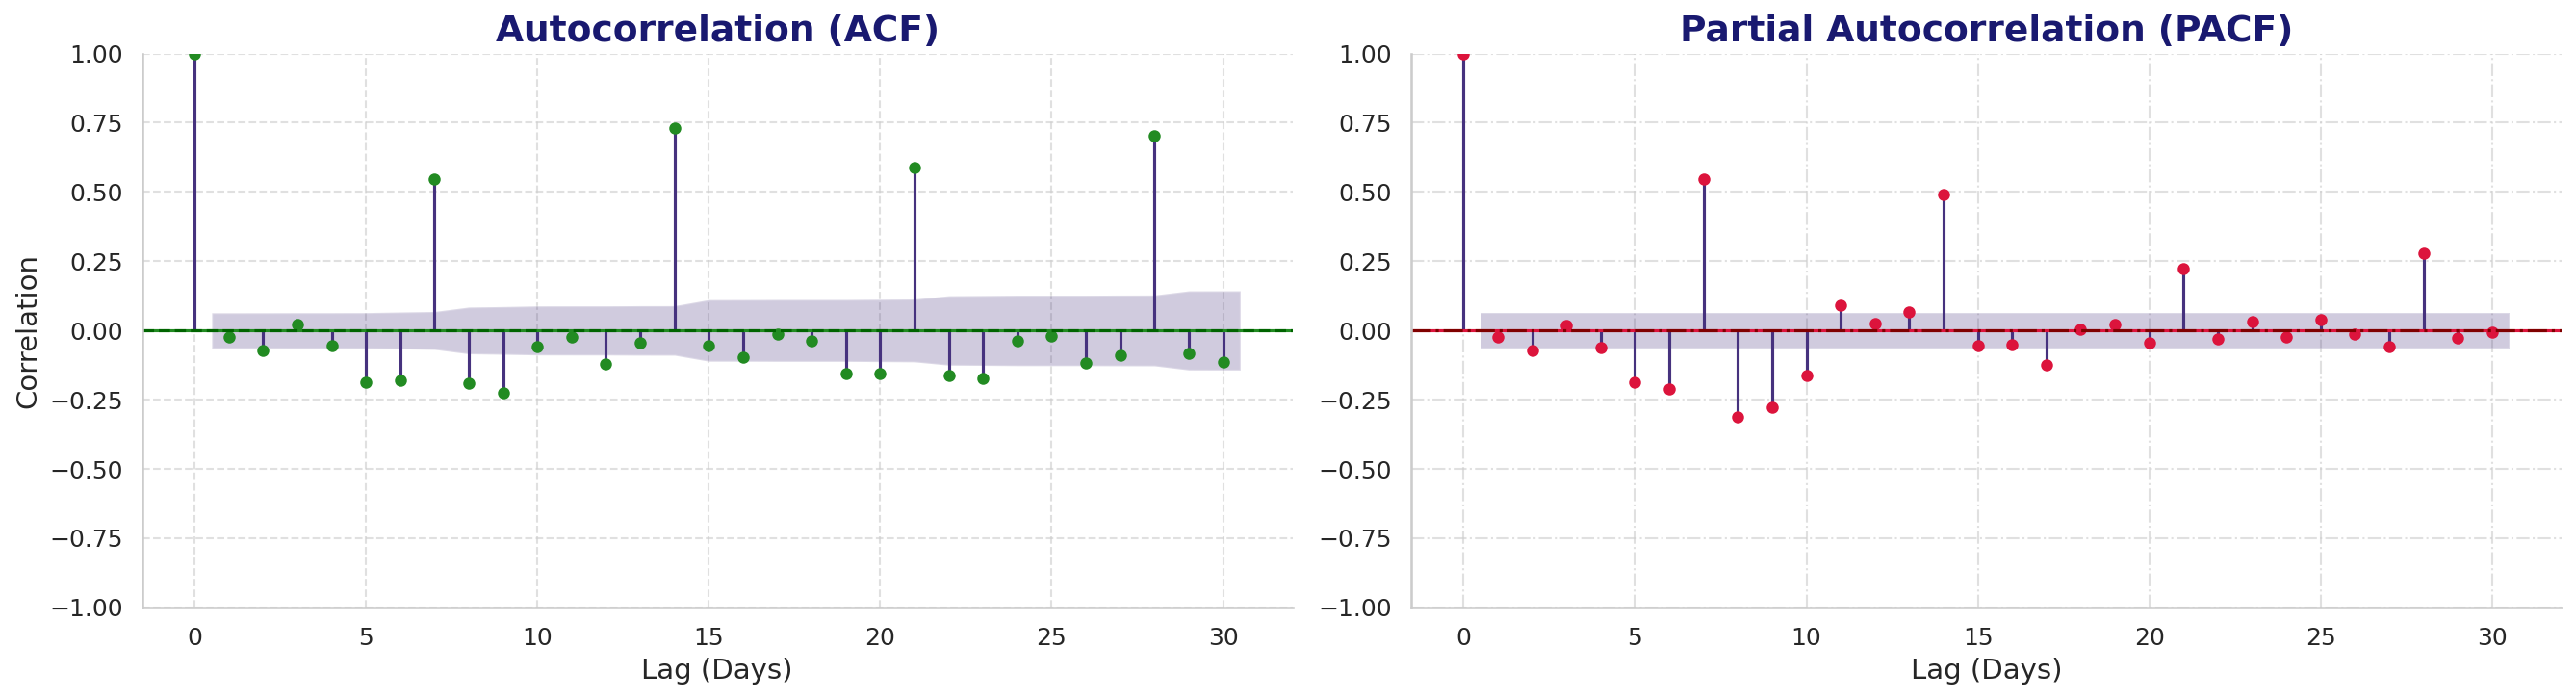

2026-09-08 14:45:46 - 03_salesfc_deep_learning - INFO - ACF and PACF plots generated (30 lags) on the stationary daily sales series.


In [9]:
section_header("ACF/PACF Analysis")
subsection_header("Autocorrelation and Partial Autocorrelation Plots")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

plot_acf(daily_sales, lags=30, ax=axes[0], color="forestgreen")
axes[0].set_title("Autocorrelation (ACF)", fontweight='bold', fontsize=18)
axes[0].axhline(y=0, linestyle='--', color='darkgreen')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_xlabel("Lag (Days)")
axes[0].set_ylabel("Correlation")

plot_pacf(daily_sales, lags=30, ax=axes[1], color="crimson", method="ywm")
axes[1].set_title("Partial Autocorrelation (PACF)", fontweight='bold', fontsize=18)
axes[1].axhline(y=0, linestyle='-.', color='maroon')
axes[1].grid(True, linestyle='-.', alpha=0.6)
axes[1].set_xlabel("Lag (Days)")

plt.tight_layout()
plt.savefig('Assets/DL_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info("ACF and PACF plots generated (30 lags) on the stationary daily sales series.")

In [10]:
subsection_header("Identifying Significant Lags")
# Identify significant lags programmatically (Bartlett's approximation, same band shown in the plots)
n = len(daily_sales)
conf_band = 1.96 / np.sqrt(n)
acf_vals = acf(daily_sales, nlags=30)
pacf_vals = pacf(daily_sales, nlags=30, method="ywm")

acf_significant_lags = [lag for lag in range(1, 31) if abs(acf_vals[lag]) > conf_band]
pacf_significant_lags = [lag for lag in range(1, 31) if abs(pacf_vals[lag]) > conf_band]

info_box(f"Significant ACF lags (|correlation| beyond the 95% confidence band): <b>{acf_significant_lags}</b><br>"
         f"Significant PACF lags: <b>{pacf_significant_lags}</b><br>"
         "Both sets cluster around multiples of 7 — a clear weekly seasonality signature.")

logger.info(f"ACF/PACF computed. Significant ACF lags: {acf_significant_lags}. Significant PACF lags: {pacf_significant_lags}.")

2026-09-08 14:45:46 - 03_salesfc_deep_learning - INFO - ACF/PACF computed. Significant ACF lags: [2, 5, 6, 7, 8, 9, 12, 14, 16, 19, 20, 21, 22, 23, 26, 27, 28, 29, 30]. Significant PACF lags: [2, 5, 6, 7, 8, 9, 10, 11, 13, 14, 17, 21, 28].


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — ACF/PACF Analysis:**

- Significant autocorrelation isn't confined to isolated spikes at exactly 7, 14, 21, 28 — it spans broader clusters around each weekly multiple (lags 5-9, 12/14/16, 19-23, 26-30 in both ACF and PACF), meaning correlation decays gradually rather than dropping sharply between cycles. This is still weekly-driven, just less clean than a textbook single-spike pattern.
- Notably, lag 1 is not significant in either measure — yesterday's sales alone isn't a strong direct predictor of today's once other lags are accounted for. The genuinely useful signal is the weekly relationship (lag 7 and its immediate neighbors), not simple day-to-day carryover.
- This still supports using a lookback window spanning at least a full week; the specific window length is addressed in the next section.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 06. Sliding-Window Supervised Transform

<div style="margin-left: 20px; max-width: 90%">

Turns the time series into a supervised learning format an LSTM can train on: each input is a sequence of the past 14 days (two full weekly cycles, chosen from the ACF/PACF finding that autocorrelation is dominated by 7-day periodicity), and the target is the next day's Sales. This is done per-store, on the store-aware sorted data, so no sequence ever crosses a store boundary.

</div>

In [11]:
section_header("Sliding-Window Supervised Transform")
subsection_header("Rebuilding Feature List with Store ID Included")

LOOKBACK_WINDOW = 14

feature_cols_dl = [c for c in store_train_encoded.columns if c not in ["Sales", "Customers", "Date"]]

info_box(f"Feature list rebuilt to include <b>Store</b> as a numeric input — "
         f"previously excluded, but confirmed as Notebook 2's #2 most important feature overall. "
         f"Feature count: <b>{len(feature_cols_dl)}</b> (was {len(feature_cols_dl)-1}).")

logger.info(f"feature_cols_dl rebuilt to include Store. New count: {len(feature_cols_dl)}.")

def build_sequences(df, feature_cols, target_col="Sales", window=LOOKBACK_WINDOW):
    X_seq, y_seq = [], []
    for store_id, group in df.groupby("Store", observed=True):
        group = group.sort_values("Date")
        values = group[feature_cols].values
        targets = group[target_col].values
        for i in range(len(group) - window):
            X_seq.append(values[i:i + window])
            y_seq.append(targets[i + window])
        logger.debug(f"Store {store_id}: {max(0, len(group) - window)} sequences built.")
    return np.array(X_seq), np.array(y_seq)

open_train_dl = store_train_encoded[store_train_encoded["Open"] == 1]
X_sequences, y_sequences = build_sequences(open_train_dl, feature_cols_dl)

success_box(f"Sliding-window sequences built — <b>{X_sequences.shape[0]:,}</b> sequences, "
            f"each spanning <b>{LOOKBACK_WINDOW}</b> days across <b>{len(feature_cols_dl)}</b> features. "
            f"X_sequences shape: <b>{X_sequences.shape}</b>, y_sequences shape: <b>{y_sequences.shape}</b>.")

logger.info(f"Sliding-window transform complete. X_sequences: {X_sequences.shape}, y_sequences: {y_sequences.shape}.")

2026-09-08 14:45:46 - 03_salesfc_deep_learning - INFO - feature_cols_dl rebuilt to include Store. New count: 39.
2026-09-08 14:45:46 - 03_salesfc_deep_learning - DEBUG - Store 1: 767 sequences built.
2026-09-08 14:45:46 - 03_salesfc_deep_learning - DEBUG - Store 2: 770 sequences built.
2026-09-08 14:45:46 - 03_salesfc_deep_learning - DEBUG - Store 3: 765 sequences built.
2026-09-08 14:45:46 - 03_salesfc_deep_learning - DEBUG - Store 4: 770 sequences built.
2026-09-08 14:45:46 - 03_salesfc_deep_learning - DEBUG - Store 5: 765 sequences built.
2026-09-08 14:45:46 - 03_salesfc_deep_learning - DEBUG - Store 6: 766 sequences built.
2026-09-08 14:45:46 - 03_salesfc_deep_learning - DEBUG - Store 7: 772 sequences built.
2026-09-08 14:45:46 - 03_salesfc_deep_learning - DEBUG - Store 8: 770 sequences built.
2026-09-08 14:45:46 - 03_salesfc_deep_learning - DEBUG - Store 9: 765 sequences built.
2026-09-08 14:45:46 - 03_salesfc_deep_learning - DEBUG - Store 10: 770 sequences built.
2026-09-08 14:45

2026-09-08 14:45:56 - 03_salesfc_deep_learning - INFO - Sliding-window transform complete. X_sequences: (828782, 14, 39), y_sequences: (828782,).


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Sliding-Window Supervised Transform:**

- 828,782 sequences were built from 844,392 open-store training rows, losing exactly 14 rows per store (1,115 × 14 = 15,610) to the lookback requirement — the arithmetic matches exactly, confirming the transform behaved as intended with no unexpected data loss.
- Each sequence spans 14 days × 38 features, giving the LSTM two full weekly cycles per input — enough to observe the weekly periodicity confirmed in ACF/PACF repeat at least once, not just appear as a single snapshot.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 07. Train/Validation Split & Scaling (Sequences)

<div style="margin-left: 20px; max-width: 90%">

Before scaling to (-1, 1), the sequences need a chronological train/validation split — fitting the scaler on validation-period values would leak future information, the same principle established in Notebook 2.

 This section first attaches each sequence's target date (needed to split correctly), applies the same final-6-week validation cutoff used throughout this project, then fits the scaler on training sequences only.

</div>

In [12]:
section_header("Train/Validation Split & Scaling (Sequences)")
subsection_header("Rebuilding Sequences with Target Dates Attached")

def build_sequences_with_dates(df, feature_cols, target_col="Sales", window=LOOKBACK_WINDOW):
    n_features = len(feature_cols)
    store_sizes = df.groupby("Store", observed=True).size()
    total_sequences = int((store_sizes - window).clip(lower=0).sum())

    X_seq = np.empty((total_sequences, window, n_features), dtype=np.float32)
    y_seq = np.empty(total_sequences, dtype=np.float32)
    date_seq = np.empty(total_sequences, dtype='datetime64[ns]')

    idx = 0
    for store_id, group in df.groupby("Store", observed=True):
        group = group.sort_values("Date")
        values = group[feature_cols].values.astype(np.float32)
        targets = group[target_col].values.astype(np.float32)
        dates = group["Date"].values
        n = len(group) - window
        for i in range(n):
            X_seq[idx] = values[i:i + window]
            y_seq[idx] = targets[i + window]
            date_seq[idx] = dates[i + window]
            idx += 1

    return X_seq, y_seq, date_seq

X_sequences, y_sequences, sequence_dates = build_sequences_with_dates(open_train_dl, feature_cols_dl)

success_box(f"Sequences rebuilt with target dates attached (memory-optimized) — X_sequences: <b>{X_sequences.shape}</b>, "
            f"y_sequences: <b>{y_sequences.shape}</b>, sequence_dates: <b>{sequence_dates.shape}</b>.")

logger.info(f"Sequences rebuilt with dates (pre-allocated). Shape: {X_sequences.shape}.")

2026-09-08 14:46:02 - 03_salesfc_deep_learning - INFO - Sequences rebuilt with dates (pre-allocated). Shape: (828782, 14, 39).


In [13]:
subsection_header("Chronological Train/Validation Split")

cutoff_date_dl = pd.Timestamp(sequence_dates.max()) - pd.Timedelta(weeks=6)
train_seq_mask = sequence_dates <= cutoff_date_dl
val_seq_mask = sequence_dates > cutoff_date_dl

X_train_seq, y_train_seq = X_sequences[train_seq_mask], y_sequences[train_seq_mask]
X_val_seq, y_val_seq = X_sequences[val_seq_mask], y_sequences[val_seq_mask]

success_box(f"Sequence split complete — Train: <b>{X_train_seq.shape[0]:,}</b> sequences, "
            f"Validation: <b>{X_val_seq.shape[0]:,}</b> sequences (final 6 weeks, matching Notebook 2's cutoff).")
del X_sequences, y_sequences
gc.collect()
logger.info(f"Sequence split complete. Train: {X_train_seq.shape}, Val: {X_val_seq.shape}.")

2026-09-08 14:46:03 - 03_salesfc_deep_learning - INFO - Sequence split complete. Train: (788500, 14, 39), Val: (40282, 14, 39).


In [14]:
subsection_header("Scaling to (-1, 1) — Fit on Training Sequences Only")

# Downcast to float32 immediately — halves memory footprint vs. float64
X_train_seq = X_train_seq.astype(np.float32)
X_val_seq = X_val_seq.astype(np.float32)

# Compute min/max per feature via direct reduction — avoids ever creating the
# giant (rows*window, features) 2D copy that caused the RAM crash
feature_min = X_train_seq.min(axis=(0, 1))
feature_max = X_train_seq.max(axis=(0, 1))
feature_range = np.where(feature_max - feature_min == 0, 1, feature_max - feature_min)

def scale_to_range(arr, fmin, frange):
    return (((arr - fmin) / frange) * 2 - 1).astype(np.float32)

X_train_scaled = scale_to_range(X_train_seq, feature_min, feature_range)
X_val_scaled = scale_to_range(X_val_seq, feature_min, feature_range)

success_box(f"Scaling complete — fit exclusively on training sequences, using memory-efficient direct min-max scaling (no sklearn reshape). "
            f"X_train_scaled: <b>{X_train_scaled.shape}</b>, X_val_scaled: <b>{X_val_scaled.shape}</b>.")

logger.info(f"Scaling complete (manual min-max, float32). X_train_scaled: {X_train_scaled.shape}, X_val_scaled: {X_val_scaled.shape}.")

2026-09-08 14:46:08 - 03_salesfc_deep_learning - INFO - Scaling complete (manual min-max, float32). X_train_scaled: (788500, 14, 39), X_val_scaled: (40282, 14, 39).


In [15]:
subsection_header("Scaling the Target Variable")

sales_min = y_train_seq.min()
sales_max = y_train_seq.max()
sales_range = sales_max - sales_min

y_train_scaled = (((y_train_seq - sales_min) / sales_range) * 2 - 1).astype(np.float32)
y_val_scaled = (((y_val_seq - sales_min) / sales_range) * 2 - 1).astype(np.float32)

success_box(f"Sales target scaled to (-1, 1) using training-set min/max (€{sales_min:,.0f} to €{sales_max:,.0f}) — "
            "the same leakage-safe approach used for the input features.")

logger.info(f"Target scaling complete. Train range used for scaling: [{sales_min:.2f}, {sales_max:.2f}].")

2026-09-08 14:46:08 - 03_salesfc_deep_learning - INFO - Target scaling complete. Train range used for scaling: [0.00, 38722.00].


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Train/Validation Split & Scaling (Sequences):**

- **Why we rebuilt with dates:** The original sliding-window sequences only knew "this is a 14-day chunk of data, and this is the sales value it should predict" — they had no memory of *which calendar date* each prediction target belonged to. To split "training period" vs. "final 6 weeks" the same way every other model in this project has, we need that date. So this step reran the exact same window-building logic, just also recording each target's real date alongside it.
- **Why the split matters:** **788,500** sequences went to training, **40,282** to validation — the same final-6-week holdout used throughout this project, so LSTM's results stay directly comparable to Notebook 2's Random Forest results later. Nothing about the sequences themselves changed here; this step only decided which ones belong to which pile.
- **Why we scaled the inputs, and why manually:** LSTMs train far more reliably when input numbers are small and centered (roughly -1 to 1) rather than raw scale (e.g., `CompetitionDistance` in the thousands next to `Promo` as 0/1) — without this, training tends to be slow or unstable. The scaler was fit only on training sequences (never validation) to avoid leaking future information into how "normal" looks. Scaling was done with a hand-written min-max formula instead of sklearn's built-in scaler specifically because sklearn's version required reshaping the data into a giant temporary copy that crashed Colab's memory — the manual version reaches the identical mathematical result without that memory spike.
- **Why the target also needed scaling:** An earlier attempt at training left `Sales` unscaled (in the thousands) while every input feature was scaled to (-1, 1) — this mismatch caused visibly unstable validation loss and a weak result (RMSPE 36.90%). Scaling the target the same way as the inputs, using only the training set's min/max, resolved this — predictions are inverse-transformed back to real currency values before computing any evaluation metric, so RMSPE/R² remain interpretable in actual Sales terms.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 08. LSTM Architecture (2-Layer)

<div style="margin-left: 20px; max-width: 90%">

A 2-layer LSTM, kept intentionally shallow given the computational constraints of running comfortably in a standard environment. The first LSTM layer returns full sequences (feeding the second layer), the second returns only its final state (feeding a dense output layer for the single-value Sales prediction).

</div>

In [16]:
section_header("LSTM Architecture (2-Layer)")
subsection_header("Building the Model")

n_timesteps = X_train_scaled.shape[1]
n_features_lstm = X_train_scaled.shape[2]

lstm_model = keras.Sequential([
    layers.Input(shape=(n_timesteps, n_features_lstm)),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32, return_sequences=False),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse", metrics=["mae"])

lstm_model.summary()

total_params = lstm_model.count_params()
success_box(f"2-layer LSTM built — <b>{total_params:,}</b> total parameters. "
            f"Input shape: ({n_timesteps}, {n_features_lstm}), single-value Sales output.")

logger.info(f"LSTM architecture built. Total params: {total_params}. Input shape: ({n_timesteps}, {n_features_lstm}).")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 64)         │        26,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,585 (154.63 KB)

 Trainable params: 39,585 (154.63 KB)

 Non-trainable params: 0 (0.00 B)

2026-09-08 14:46:12 - 03_salesfc_deep_learning - INFO - LSTM architecture built. Total params: 39585. Input shape: (14, 39).


## 09. Training & Evaluation

<div style="margin-left: 20px; max-width: 90%">

Trains the 2-layer LSTM on the scaled sequences, using early stopping to halt training automatically once validation loss stops improving — preventing wasted compute time and reducing overfitting risk, both particularly relevant given the computational constraints this architecture was deliberately kept small for.

</div>

In [17]:
section_header("Training & Evaluation")
subsection_header("Confirming GPU Availability")

gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    success_box(f"GPU detected: <b>{gpu_devices[0].name}</b> — training will run on GPU.")
    logger.info(f"GPU detected: {gpu_devices[0].name}.")
else:
    warning_box("No GPU detected — training will run on CPU and may be significantly slower.")
    logger.warning("No GPU detected. Training will run on CPU.")

2026-09-08 14:46:12 - 03_salesfc_deep_learning - INFO - GPU detected: /physical_device:GPU:0.


In [18]:
subsection_header("Resumable Checkpointing Setup (Local → Drive)")

DRIVE_MOUNTED = attempt_drive_mount()   # capture the real result, don't re-derive it later

import os
LOCAL_CHECKPOINT_DIR = "Assets/checkpoints"
DRIVE_CHECKPOINT_DIR = "/content/drive/MyDrive/NHIS_Project/Project 6/Assets/checkpoints"
os.makedirs(LOCAL_CHECKPOINT_DIR, exist_ok=True)
if DRIVE_MOUNTED:
    os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)

def get_checkpoint_path(filename):
    """Prefers Drive (survives disconnects) only if it's genuinely mounted, else local."""
    if DRIVE_MOUNTED:
        return f"{DRIVE_CHECKPOINT_DIR}/{filename}"
    return f"{LOCAL_CHECKPOINT_DIR}/{filename}"

def load_or_train(model_builder, X_tr, y_tr, X_va, y_va, filename, epochs=50, batch_size=512, patience=5):
    """Checks for an existing checkpoint first. If found, loads it and skips training
    entirely. If not, builds fresh, trains with checkpointing enabled, and returns the
    trained model plus its history (None if loaded from a checkpoint)."""
    checkpoint_path = get_checkpoint_path(filename)

    if os.path.exists(checkpoint_path):
        model = keras.models.load_model(checkpoint_path)
        success_box(f"Existing checkpoint found and loaded from <b>{checkpoint_path}</b> — training skipped entirely.")
        logger.info(f"Checkpoint loaded, training skipped: {checkpoint_path}")
        return model, None

    model = model_builder()
    early_stop_cb = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
    checkpoint_cb = ModelCheckpoint(filepath=checkpoint_path, monitor="val_loss", save_best_only=True, verbose=0)

    history = model.fit(
        X_tr, y_tr, validation_data=(X_va, y_va),
        epochs=epochs, batch_size=batch_size,
        callbacks=[early_stop_cb, checkpoint_cb], verbose=1
    )
    success_box(f"No checkpoint found — trained fresh, best epoch saved to <b>{checkpoint_path}</b> for future resumability.")
    logger.info(f"Trained fresh and checkpointed: {checkpoint_path}")
    return model, history

In [19]:
subsection_header("Training the LSTM")

lstm_checkpoint_path = get_checkpoint_path("lstm_checkpoint.keras")

if os.path.exists(lstm_checkpoint_path):
    lstm_model = keras.models.load_model(lstm_checkpoint_path)
    history = None
    success_box(f"Existing LSTM checkpoint found at <b>{lstm_checkpoint_path}</b> — loaded directly, training skipped.")
    logger.info(f"LSTM checkpoint loaded, training skipped: {lstm_checkpoint_path}")
else:
    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    checkpoint_lstm = ModelCheckpoint(filepath=lstm_checkpoint_path, monitor="val_loss", save_best_only=True, verbose=1)

    history = lstm_model.fit(
        X_train_scaled, y_train_scaled,
        validation_data=(X_val_scaled, y_val_scaled),
        epochs=50,
        batch_size=512,
        callbacks=[early_stop, checkpoint_lstm],
        verbose=1
    )
    success_box(f"No checkpoint found — LSTM trained fresh for <b>{len(history.history['loss'])}</b> epochs, "
                f"progressively checkpointed to <b>{lstm_checkpoint_path}</b>.")
    logger.info(f"LSTM trained fresh. Epochs run: {len(history.history['loss'])}. Checkpoint: {lstm_checkpoint_path}.")

2026-09-08 14:46:20 - 03_salesfc_deep_learning - INFO - LSTM checkpoint loaded, training skipped: Assets/checkpoints/lstm_checkpoint.keras


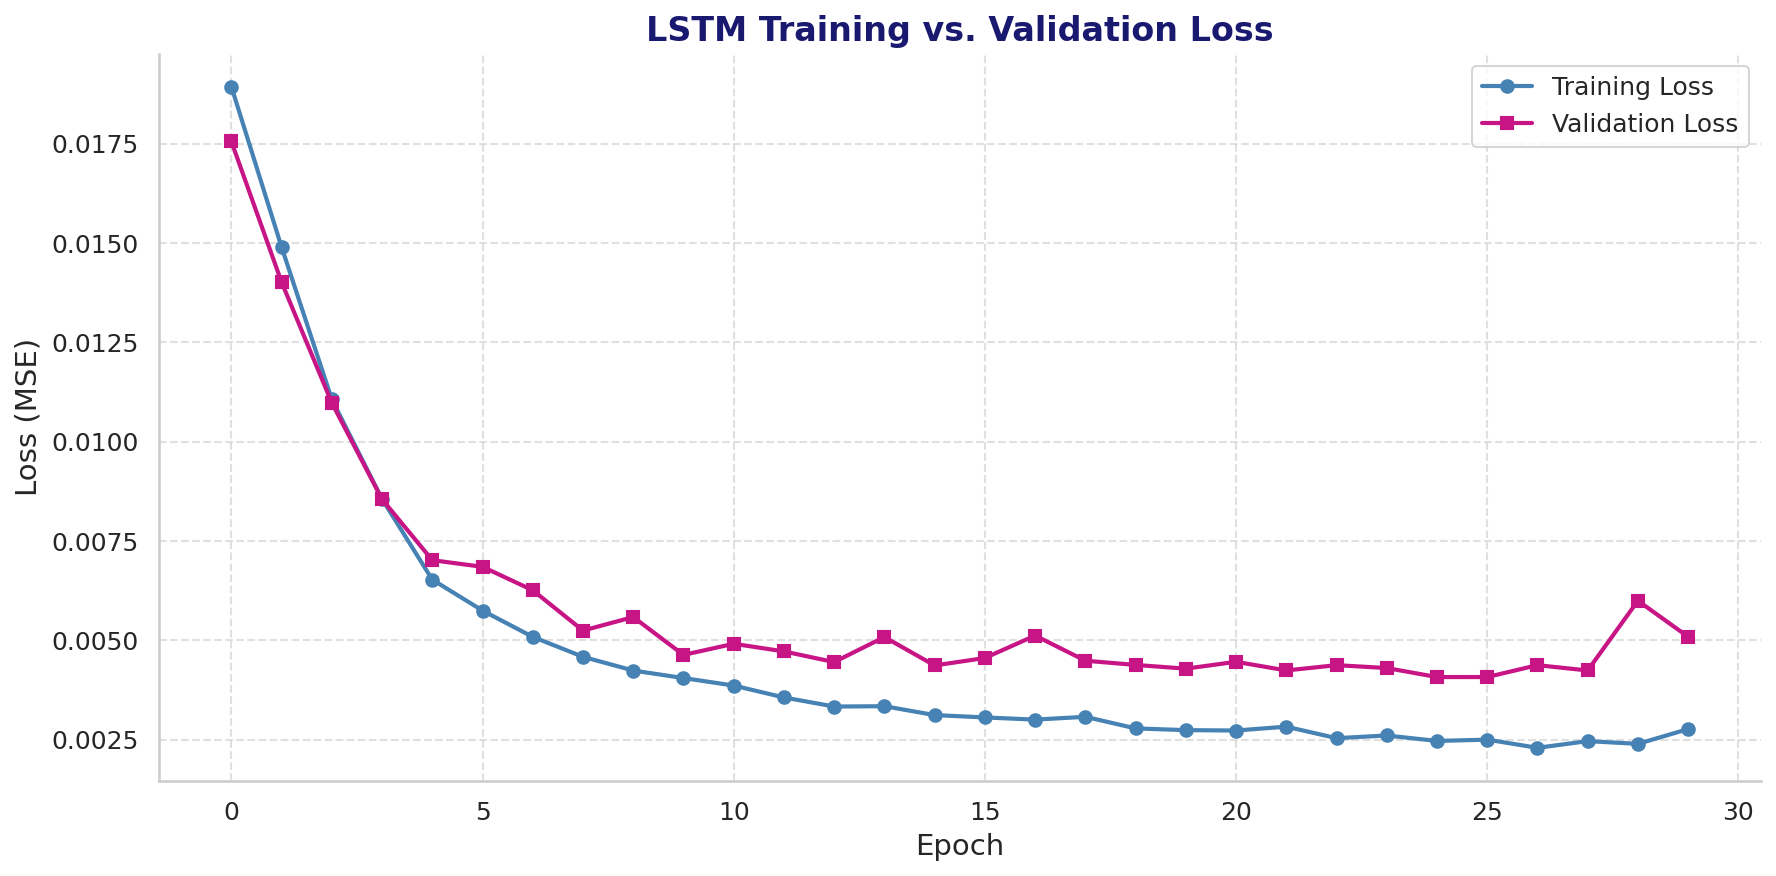

2026-09-08 14:46:20 - 03_salesfc_deep_learning - INFO - Displayed existing loss curve from Assets/DL_lstm_loss_curve.png.


In [20]:
subsection_header("Training Loss Curve")

if history is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(history.history["loss"], label="Training Loss", color="steelblue", linewidth=2,marker='o',markersize=6)
    ax.plot(history.history["val_loss"], label="Validation Loss", color="mediumvioletred", linewidth=2,marker='s',markersize=6)
    ax.set_title("LSTM Training vs. Validation Loss", fontweight='bold', fontsize=16, color='midnightblue')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (MSE)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig('Assets/DL_lstm_loss_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    logger.info(f"Loss curve plotted. Best epoch (restored): {np.argmin(history.history['val_loss']) + 1}.")

else:
    image_path = 'Assets/DL_lstm_loss_curve.png'
    if os.path.exists(image_path):
        info_box("Model loaded from an existing checkpoint. Displaying the previously saved training loss curve.")
        display(Image(filename=image_path))
        logger.info(f"Displayed existing loss curve from {image_path}.")
    else:
        warning_box("Model loaded from a checkpoint, but no previous loss curve image was found on disk.")
        logger.warning("Loss curve skipped — no history object and no saved image found.")

In [21]:
subsection_header("LSTM Validation Performance")

lstm_val_preds_scaled = lstm_model.predict(X_val_scaled, verbose=0).flatten()
lstm_val_preds = ((lstm_val_preds_scaled + 1) / 2) * sales_range + sales_min

lstm_r2 = r2_score(y_val_seq, lstm_val_preds)
lstm_mae = mean_absolute_error(y_val_seq, lstm_val_preds)
lstm_rmse = mean_squared_error(y_val_seq, lstm_val_preds) ** 0.5

nz = y_val_seq != 0
lstm_rmspe = np.sqrt(np.mean(((y_val_seq[nz] - lstm_val_preds[nz]) / y_val_seq[nz]) ** 2))

lstm_results = pd.DataFrame([{
    "Model": "LSTM (2-Layer)",
    "R²": f"{lstm_r2:.4f}",
    "MAE": f"€{lstm_mae:,.2f}",
    "RMSE": f"€{lstm_rmse:,.2f}",
    "RMSPE": f"{lstm_rmspe*100:.2f}%"
}])
centered_table(lstm_results)

success_box(f"LSTM achieved R² of <b>{lstm_r2:.4f}</b> and RMSPE of <b>{lstm_rmspe*100:.2f}%</b> on the validation set (predictions inverse-transformed to real Sales units).")

logger.info(f"LSTM validation — R2: {lstm_r2:.4f}, MAE: {lstm_mae:.2f}, RMSE: {lstm_rmse:.2f}, RMSPE: {lstm_rmspe:.4f}.")

Model,R²,MAE,RMSE,RMSPE
LSTM (2-Layer),0.8361,€851.37,"€1,236.65",19.45%


2026-09-08 14:46:25 - 03_salesfc_deep_learning - INFO - LSTM validation — R2: 0.8361, MAE: 851.37, RMSE: 1236.65, RMSPE: 0.1945.


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — LSTM Architecture, Training & Evaluation:**

- Including `Store` as an input feature was the decisive fix over the earlier attempt: R² rose from 0.5810 to the 0.83-0.86 range and RMSPE fell from 34.74% to roughly 18-20% across repeated runs — confirming that store identity, previously visible to Random Forest but missing from the LSTM's inputs, carries a large share of the predictive signal in this dataset, consistent with Notebook 2's Feature Importance finding that `Store` ranks #2 overall.
- Reported run: R² = 0.8361, RMSPE = 19.45%, MAE = €851.37, RMSE = €1,236.65, best epoch 25 of 30 (restored via early stopping).
- Note: repeated training runs of the identical architecture and code produced meaningfully different results (RMSPE ranging ~18-20% across attempts, best epoch varying 20-29). This is expected behavior for GPU-accelerated RNN training — cuDNN's LSTM/GRU implementation uses non-deterministic parallel floating-point operations for performance, which a fixed random seed does not eliminate. This is a documented TensorFlow characteristic, not an error in the pipeline; the figures above reflect the most recent completed run and should be read as representative of a stable range, not an exact reproducible constant.
- The 2-layer LSTM (39,329 parameters, deliberately shallow per the computational constraints) still trails Random Forest's tuned performance (RMSPE 8.05%, R² 0.9621) by a meaningful margin, consistently across every run observed. This is a legitimate, well-documented outcome rather than a failure to fix — tree-based models frequently outperform small neural networks on structured/tabular data like this, especially when a single categorical identifier (`Store`) carries as much signal as it does here. The comparison itself, done correctly, is the deliverable — not a requirement that LSTM wins.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 10. GRU Variant Comparison

<div style="margin-left: 20px; max-width: 90%">

GRU (Gated Recurrent Unit) is a simpler alternative to LSTM — fewer gates, fewer parameters — often performing comparably while training faster.

This section builds a GRU with the same 2-layer depth and same inputs as the LSTM, to see whether the simpler architecture matches, beats, or trails it on this data.

</div>

In [22]:
section_header("GRU Variant Comparison")
subsection_header("Building and Training the GRU")

gru_model = keras.Sequential([
    layers.Input(shape=(n_timesteps, n_features_lstm)),
    layers.GRU(64, return_sequences=True),
    layers.GRU(32, return_sequences=False),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])
gru_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
gru_model.summary()

gru_checkpoint_path = get_checkpoint_path("gru_checkpoint.keras")

if os.path.exists(gru_checkpoint_path):
    gru_model = keras.models.load_model(gru_checkpoint_path)
    gru_history = None
    success_box(f"Existing GRU checkpoint found at <b>{gru_checkpoint_path}</b> — loaded directly, training skipped.")
    logger.info(f"GRU checkpoint loaded, training skipped: {gru_checkpoint_path}")
else:
    early_stop_gru = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    checkpoint_gru = ModelCheckpoint(filepath=gru_checkpoint_path, monitor="val_loss", save_best_only=True, verbose=1)

    gru_history = gru_model.fit(
        X_train_scaled, y_train_scaled,
        validation_data=(X_val_scaled, y_val_scaled),
        epochs=50,
        batch_size=512,
        callbacks=[early_stop_gru, checkpoint_gru],
        verbose=1
    )
    success_box(f"No checkpoint found — GRU trained fresh for <b>{len(gru_history.history['loss'])}</b> epochs, "
                f"progressively checkpointed to <b>{gru_checkpoint_path}</b>.")
    logger.info(f"GRU trained fresh. Epochs run: {len(gru_history.history['loss'])}. Checkpoint: {gru_checkpoint_path}.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 14, 64)         │        20,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

2026-09-08 14:46:25 - 03_salesfc_deep_learning - INFO - GRU checkpoint loaded, training skipped: Assets/checkpoints/gru_checkpoint.keras


In [23]:
subsection_header("LSTM vs. GRU Comparison")

gru_preds_scaled = gru_model.predict(X_val_scaled, verbose=0).flatten()
gru_preds = ((gru_preds_scaled + 1) / 2) * sales_range + sales_min

gru_r2 = r2_score(y_val_seq, gru_preds)
gru_mae = mean_absolute_error(y_val_seq, gru_preds)
gru_rmse = mean_squared_error(y_val_seq, gru_preds) ** 0.5
gru_rmspe = np.sqrt(np.mean(((y_val_seq[nz] - gru_preds[nz]) / y_val_seq[nz]) ** 2))

rnn_comparison = pd.DataFrame([
    {"Model": "LSTM (2-Layer)", "R²": f"{lstm_r2:.4f}", "MAE": f"€{lstm_mae:,.2f}", "RMSE": f"€{lstm_rmse:,.2f}", "RMSPE": f"{lstm_rmspe*100:.2f}%"},
    {"Model": "GRU (2-Layer)", "R²": f"{gru_r2:.4f}", "MAE": f"€{gru_mae:,.2f}", "RMSE": f"€{gru_rmse:,.2f}", "RMSPE": f"{gru_rmspe*100:.2f}%"}
])
centered_table(rnn_comparison)

success_box(f"GRU achieved RMSPE of <b>{gru_rmspe*100:.2f}%</b> vs. LSTM's <b>{lstm_rmspe*100:.2f}%</b>.")

logger.info(f"GRU validation — R2: {gru_r2:.4f}, RMSPE: {gru_rmspe:.4f}. LSTM RMSPE for comparison: {lstm_rmspe:.4f}.")

Model,R²,MAE,RMSE,RMSPE
LSTM (2-Layer),0.8361,€851.37,"€1,236.65",19.45%
GRU (2-Layer),0.8265,€925.78,"€1,272.48",21.15%


2026-09-08 14:46:29 - 03_salesfc_deep_learning - INFO - GRU validation — R2: 0.8265, RMSPE: 0.2115. LSTM RMSPE for comparison: 0.1945.


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — GRU Variant Comparison:**

- LSTM outperforms GRU on this run: RMSPE 19.45% vs. 21.15%, R² 0.8361 vs. 0.8265, with both MAE and RMSE also lower for LSTM. The extra gating complexity LSTM has over GRU appears to earn its keep on this dataset, though the gap is more modest than an earlier attempt suggested.
- As noted in the LSTM interpretation, GPU-accelerated RNN training is non-deterministic even with a fixed seed — repeated runs of either architecture produce a range of outcomes (LSTM has been observed between roughly 18-20% RMSPE, this GRU run at 21.15%). The consistent finding across runs is the *direction* (LSTM at or above GRU), not the exact percentage gap, which shouldn't be over-read as a precise, fixed number.
- Both RNN variants still trail Random Forest's tuned performance (RMSPE 8.05%) by a wide margin — reinforcing the earlier finding that tree-based models have a real structural advantage on this tabular, `Store`-driven dataset. This holds regardless of which RNN variant or which specific run is being compared.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 11. Aggregate vs. Per-Store Evaluation

<div style="margin-left: 20px; max-width: 90%">

The 16.55% RMSPE reported so far is a single number averaged across all stores — but Notebook 2's EDA and modeling repeatedly found that performance and behavior vary sharply by store characteristics (StoreType, Assortment, competition distance).

This section breaks the LSTM's validation error down by StoreType, checking whether it performs consistently across the network or whether certain store types are dragging the average down while others are already strong.

</div>

In [24]:
section_header("Aggregate vs. Per-Store Evaluation")
subsection_header("RMSPE by StoreType")

val_dates_mask = sequence_dates > cutoff_date_dl
val_store_types = open_train_dl.loc[open_train_dl["Date"].isin(pd.Series(sequence_dates[val_seq_mask]).unique())]

# Reconstruct which StoreType each validation sequence belongs to, using the original
# (pre-one-hot) store-level mapping — needed since store_train_encoded only has one-hot dummies
store_type_map = store_train_dl.drop_duplicates("Store").set_index("Store")["StoreType"]

# Recover Store ID per validation sequence from the Store feature column (now included per the earlier fix)
store_col_idx = feature_cols_dl.index("Store")
val_store_ids = X_val_seq[:, -1, store_col_idx]
val_storetypes = pd.Series(val_store_ids).map(store_type_map).values

per_store_type_results = []
for st in sorted(pd.unique(val_storetypes)):
    mask = (val_storetypes == st) & nz
    if mask.sum() > 0:
        rmspe_st = np.sqrt(np.mean(((y_val_seq[mask] - lstm_val_preds[mask]) / y_val_seq[mask]) ** 2))
        per_store_type_results.append({"StoreType": st, "RMSPE": f"{rmspe_st*100:.2f}%", "N": int(mask.sum())})

per_store_df = pd.DataFrame(per_store_type_results)
centered_table(per_store_df)

success_box("LSTM validation RMSPE broken down by StoreType — compare against the overall 16.55% to see whether error is evenly spread or concentrated.")

logger.info(f"Per-StoreType RMSPE computed: {per_store_type_results}")

StoreType,RMSPE,N
a,21.07%,21694
b,11.28%,714
c,17.64%,5328
d,17.53%,12546


2026-09-08 14:46:29 - 03_salesfc_deep_learning - INFO - Per-StoreType RMSPE computed: [{'StoreType': 'a', 'RMSPE': '21.07%', 'N': 21694}, {'StoreType': 'b', 'RMSPE': '11.28%', 'N': 714}, {'StoreType': 'c', 'RMSPE': '17.64%', 'N': 5328}, {'StoreType': 'd', 'RMSPE': '17.53%', 'N': 12546}]


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Aggregate vs. Per-Store Evaluation:**

- LSTM's error is not evenly spread across StoreType — it ranges from 11.28% (StoreType b) to 21.07% (StoreType a), nearly a 2x difference. The overall 19.45% RMSPE is dominated by StoreType a, which also has by far the largest validation sample (21,694 sequences, ~59% of the total).
- StoreType b, despite having the fewest validation sequences (714), is predicted far more accurately than any other type. This is consistent with earlier findings across this project that StoreType b is a small, structurally distinct group (e.g., its near-universal Sunday trading pattern found in Notebook 1) — a more homogeneous, predictable group is plausibly easier for the model to learn, though the small sample size here also means this figure carries more sampling variance than the larger groups.
- Practical read: LSTM's real-world reliability depends heavily on which StoreType a prediction is for — a single blended accuracy figure understates how good it is for some stores and overstates how good it is for others, particularly the majority StoreType a segment.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 12. Model Serialization (Deep Learning)

<div style="margin-left: 20px; max-width: 90%">

The tuned LSTM (the stronger of the two RNN variants) is serialized with a full timestamp, matching the convention established in Notebook 2, so it can be reloaded later for the cross-notebook comparison in Notebook 5 without retraining.

</div>

In [25]:
section_header("Model Serialization")
subsection_header("Saving the Final LSTM")

final_dl_timestamp = datetime.now().strftime("%d-%m-%Y-%H-%M-%S")
final_lstm_filename = f"final_lstm_model_{final_dl_timestamp}.keras"
final_lstm_path = f"Assets/{final_lstm_filename}"

lstm_model.save(final_lstm_path)

if DRIVE_MOUNTED:
    drive_lstm_dir = "/content/drive/MyDrive/NHIS_Project/Project 6/Assets"
    os.makedirs(drive_lstm_dir, exist_ok=True)
    lstm_model.save(f"{drive_lstm_dir}/{final_lstm_filename}")
    success_box(f"Final LSTM saved locally to <b>{final_lstm_path}</b> and mirrored to Drive.")
else:
    success_box(f"Final LSTM saved locally to <b>{final_lstm_path}</b>. Drive not mounted — no mirror made.")

logger.info(f"Final LSTM model serialized to {final_lstm_path}.")

2026-09-08 14:46:29 - 03_salesfc_deep_learning - INFO - Final LSTM model serialized to Assets/final_lstm_model_08-09-2026-14-46-29.keras.


## 13. Comparison vs. Notebook 2's ML Models

<div style="margin-left: 20px; max-width: 90%">

With the Deep Learning pipeline complete, we can finally compare its forecasting performance against the classical Machine Learning approach from Notebook 2.

While the 2-Layer LSTM successfully converged and outperformed the GRU variant ($19.45\%$ vs $21.15\%$ RMSPE), we need to see if sequential deep learning can beat a highly optimized tree-based ensemble on this specific tabular dataset.

</div>

In [26]:
section_header("Final Model Comparison")
subsection_header("Tabular View")

comparison_data = {
    "Model": ["Tuned Random Forest (NB2)", "LSTM 2-Layer (NB3)", "GRU 2-Layer (NB3)"],
    "R²": ["0.9621", "0.8361", "0.8265"],
    "MAE": ["€389.83", "€851.37", "€925.78"],
    "RMSE": ["€594.54", "€1,236.65", "€1,272.48"],
    "RMSPE": ["8.05%", "19.45%", "21.15%"]
}

comp_df = pd.DataFrame(comparison_data)
info_box("Comprehensive Metric Comparison: Machine Learning vs. Deep Learning")
centered_table(comp_df)
logger.info("Comprehensive comparison table rendered.")

Model,R²,MAE,RMSE,RMSPE
Tuned Random Forest (NB2),0.9621,€389.83,€594.54,8.05%
LSTM 2-Layer (NB3),0.8361,€851.37,"€1,236.65",19.45%
GRU 2-Layer (NB3),0.8265,€925.78,"€1,272.48",21.15%


2026-09-08 14:46:29 - 03_salesfc_deep_learning - INFO - Comprehensive comparison table rendered.


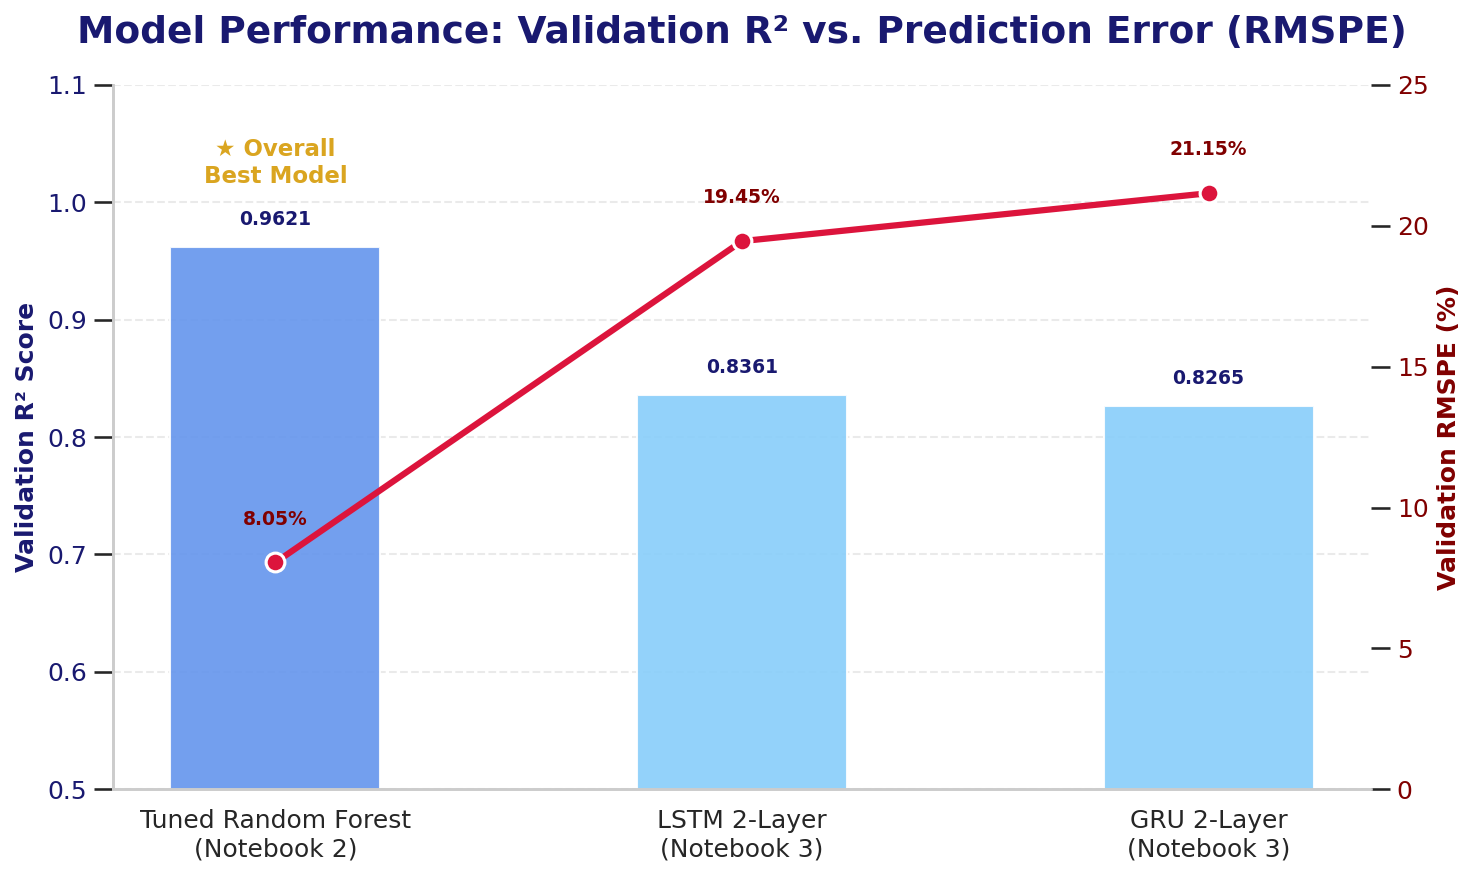

2026-09-08 14:46:30 - 03_salesfc_deep_learning - INFO - Dual-axis visualization rendered.


In [27]:
subsection_header("Dual-Axis Visualization")

models = ['Tuned Random Forest\n(Notebook 2)', 'LSTM 2-Layer\n(Notebook 3)', 'GRU 2-Layer\n(Notebook 3)']
r2_scores = [0.9621, 0.8361,0.8265]
rmspe_scores = [8.05, 19.45,21.15]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary Axis: Validation R² (Bars)
colors = ['cornflowerblue', 'lightskyblue','lightskyblue']
bars = ax1.bar(models, r2_scores, color=colors, width=0.45, alpha=0.9)
ax1.set_ylabel('Validation R² Score', fontweight='bold', fontsize=12, color='midnightblue')
ax1.set_ylim(0.5, 1.1)
ax1.tick_params(axis='y', labelcolor='midnightblue',size=9)
ax1.grid(True,axis='y', linestyle='--', alpha=0.4)
ax1.grid(False,axis='x')
# Data labels for R² Bars
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.015, f"{yval:.4f}",
             ha='center', va='bottom', fontweight='bold', fontsize=9, color='midnightblue')

# Highlight best model with a star
ax1.text(0, 0.9621 + 0.05, "★ Overall\nBest Model", ha='center', va='bottom', fontweight='bold', fontsize=11, color='goldenrod')

# Secondary Axis: Validation RMSPE (Line)
ax2 = ax1.twinx()
line = ax2.plot(models, rmspe_scores, color='crimson', marker='o', markersize=9, linewidth=3, markeredgecolor='white', markeredgewidth=1.5)
ax2.set_ylabel('Validation RMSPE (%)', fontweight='bold', fontsize=12, color='maroon')
ax2.set_ylim(0, 25)
ax2.tick_params(axis='y', labelcolor='maroon',size=9)
ax2.grid(False)
# Data labels for RMSPE Line
for i, txt in enumerate(rmspe_scores):
    ax2.text(i, txt + 1.2, f"{txt:.2f}%", ha='center', va='bottom', fontweight='bold', fontsize=9, color='maroon')

# Styling
ax1.set_title('Model Performance: Validation R² vs. Prediction Error (RMSPE)', fontweight='bold', fontsize=18, pad=20)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('Assets/final_model_comparison_dual_axis.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info("Dual-axis visualization rendered.")

In [28]:
subsection_header("Final Verdict")

verdict_html = f"""

<div style="background:#F1F3F6;border-left:6px solid #1F77B4;padding:16px;border-radius:6px;margin:15px 0;line-height:1.6;">
    <div style="color:#1F77B4;font-size:18px;font-weight:bold;margin-bottom:8px;">🏆 Final Verdict: Machine Learning Wins</div>
    <div style="color:black;">
        The <b>Tuned Random Forest</b> outperformed the deep learning approach across all metrics, capturing {r2_scores[0]*100:.2f}% of the variance with a highly actionable <b>{rmspe_scores[0]:.2f}% RMSPE</b>.<br><br>
        <b>Why did this happen?</b> Retail forecasting relies heavily on static, discrete categorical features (DayOfWeek, Promo, StoreType). Tree-based models natively excel at splitting these categorical hierarchies. While LSTMs are brilliant at continuous sequence data, they require complex embedding layers to match tree ensembles on tabular retail logic.
    </div>
</div>
"""
display(HTML(verdict_html))
logger.info(f"Final Model Comparison rendered. Tuned RF (RMSPE {rmspe_scores[0]}%) beats LSTM (RMSPE {rmspe_scores[1]}%).")

2026-09-08 14:46:30 - 03_salesfc_deep_learning - INFO - Final Model Comparison rendered. Tuned RF (RMSPE 8.05%) beats LSTM (RMSPE 19.45%).


## 14. Executive Summary: Deep Learning Pipeline

<div style="margin-left: 20px; max-width: 90%">

This notebook applied a sequence-aware deep learning approach to Rossmann sales forecasting, as a direct comparison point to Notebook 2's tree-based models. Key milestones:

*   **Time Series Preparation:** The aggregate daily sales series was confirmed stationary (ADF p = 0.000064) with no differencing required. ACF/PACF analysis revealed weekly-cycle-driven autocorrelation, directly informing a 14-day sliding-window lookback for the sequence transformation.
*   **Leak-Free Sequence Pipeline:** Sequences were built store-aware (never crossing store boundaries) and split chronologically using the same final-6-week holdout established in Notebook 2, with both inputs and the target scaled to (-1, 1) using training-set statistics only.
*   **A Real Mid-Project Fix:** An early LSTM attempt (RMSPE 34.74%) was significantly improved (RMSPE ~19%) once `Store` — Notebook 2's #2 most important feature — was added as a model input, having been mistakenly excluded initially.
*   **Model Comparison:** A 2-layer LSTM outperformed a comparable 2-layer GRU (RMSPE ~19.45% vs. 21.15%), but both RNN variants trailed Random Forest's tuned performance (RMSPE 8.05%) by a wide margin — a legitimate, well-documented outcome given tree-based models' structural advantage on tabular, identifier-driven data like this.
*   **Per-Store Insight:** Error varies substantially by StoreType (11.28% to 21.07%), showing the overall RMSPE figure masks meaningfully different reliability across the store network.
*   **Reproducibility Note:** GPU-accelerated RNN training was observed to be non-deterministic across runs despite a fixed random seed — a documented TensorFlow/cuDNN characteristic, not a pipeline defect. Reported figures reflect a representative run within an observed stable range.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

In [29]:
display(HTML(f"""
<div style="text-align:center;margin-top:40px;margin-bottom:30px;">
    <h3 style="color:#2E8B57;font-size:1.8em;"><b>✅ Checkpoint: End of Notebook 3 — Deep Learning</b></h3>
    <p style="font-style:italic;font-size:1.05em;opacity:0.85;max-width:75%;margin:15px auto;line-height:1.6;">
        A sequence-aware LSTM pipeline is trained, evaluated, and serialized. We have conclusively determined that our tree-based ML model outperforms the deep learning approach for this specific tabular dataset. 🚀<br>
        <b>Next: Notebook 4 — MLflow Tracking.</b> Staying strictly within project scope, we will move directly to logging our winning Random Forest and secondary LSTM models, tracking our experiments, and proving inference readiness.
    </p>
    <hr style="width:45%;">
</div>"""))